# Weather Temperature Forecasting — Deep Learning Comparison

Compare **LSTM**, **SimpleRNN**, and **GRU** on the same preprocessing pipeline used in the classical ML notebook.

**Fixes from original:**
- `shuffle=False` in train/test split (temporal data must not be shuffled — shuffling causes future leakage)
- Deprecated `fillna(method='ffill')` replaced with `ffill()`
- All three models share identical data pipeline for a fair comparison
- Consistent metrics printed in the same format for easy comparison with classical ML results

## 1. Imports & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, SimpleRNN, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Kaggle path
data = pd.read_csv('/kaggle/input/datasets/mohamednasra/weather/weatherHistory.csv')
print(f'Dataset shape: {data.shape}')

2026-06-24 16:49:56.105721: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782319796.331094      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782319796.394258      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782319796.881196      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782319796.881240      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782319796.881242      58 computation_placer.cc:177] computation placer alr

Dataset shape: (96453, 12)


## 2. Preprocessing

Identical to the classical ML notebook for fair comparison.

In [2]:
# --- Date parsing ---
data['Year']  = data['Formatted Date'].str[:4].astype(int)
data['Month'] = data['Formatted Date'].str[5:7].astype(int)
data['Day']   = data['Formatted Date'].str[8:10].astype(int)
data['Hour']  = data['Formatted Date'].str[11:13].astype(int)
data.drop(columns=['Formatted Date'], inplace=True)

# --- Outlier clipping (IQR) ---
numerical_cols = data.select_dtypes(include=['number']).columns
for col in numerical_cols:
    Q1  = data[col].quantile(0.25)
    Q3  = data[col].quantile(0.75)
    IQR = Q3 - Q1
    data[col] = data[col].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)

# --- Drop non-numeric & zero-variance columns ---
data.drop(columns=['Summary', 'Daily Summary', 'Precip Type', 'Loud Cover'], inplace=True)

print('Preprocessing complete. Shape:', data.shape)
print('Columns:', data.columns.tolist())

Preprocessing complete. Shape: (96453, 11)
Columns: ['Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)', 'Pressure (millibars)', 'Year', 'Month', 'Day', 'Hour']


## 3. Feature Selection & Scaling

**Note on `Apparent Temperature`:** It is excluded here because it is a derived feature (function of Temperature × Humidity × Wind Speed), which would constitute data leakage for temperature prediction.

**Features used:** Temperature, Humidity, Visibility, Pressure — 4 direct meteorological measurements.

In [3]:
FEATURES = ['Temperature (C)', 'Humidity', 'Visibility (km)', 'Pressure (millibars)']
TARGET   = 'Temperature (C)'

features_arr = data[FEATURES].values
# Target is next-step temperature (predict 1 hour ahead)
target_arr = data[[TARGET]].shift(-1).ffill().values  # fix: ffill() replaces deprecated method

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

features_scaled = scaler_X.fit_transform(features_arr)
target_scaled   = scaler_y.fit_transform(target_arr)

print(f'Features shape: {features_scaled.shape}')
print(f'Target shape:   {target_scaled.shape}')

Features shape: (96453, 4)
Target shape:   (96453, 1)


## 4. Sequence Construction

Sliding window of `TIME_STEPS=12` — each sample is 12 consecutive hours of features predicting the next temperature.

In [4]:
TIME_STEPS = 12

X, y = [], []
for i in range(len(features_scaled) - TIME_STEPS):
    X.append(features_scaled[i : i + TIME_STEPS])
    y.append(target_scaled[i + TIME_STEPS])

X = np.array(X)  # shape: (samples, TIME_STEPS, features)
y = np.array(y)  # shape: (samples, 1)

print(f'X shape: {X.shape}')  # e.g. (96,343, 10, 4)
print(f'y shape: {y.shape}')

X shape: (96441, 12, 4)
y shape: (96441, 1)


## 5. Train / Test Split

`shuffle=False` is **required** for time series — shuffling would allow future data points to appear in training.

In [5]:
# 80/20 temporal split — NO shuffling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (77152, 12, 4)  |  Test: (19289, 12, 4)


## 6. Helper — Evaluate & Plot

Shared function used for all three models.

In [6]:
def evaluate_and_plot(model_name, y_test_orig, y_pred_orig):
    mae  = mean_absolute_error(y_test_orig, y_pred_orig)
    rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
    r2   = r2_score(y_test_orig, y_pred_orig)
    print(f'{model_name}')
    print(f'  MAE  = {mae:.4f} °C')
    print(f'  RMSE = {rmse:.4f} °C')
    print(f'  R²   = {r2:.4f}')

    plt.figure(figsize=(12, 4))
    plt.plot(y_test_orig[:300],  label='Actual',    linewidth=1.5)
    plt.plot(y_pred_orig[:300],  label=f'Predicted ({model_name})', linestyle='--', linewidth=1.5)
    plt.xlabel('Sample')
    plt.ylabel('Temperature (°C)')
    plt.title(f'Actual vs Predicted — {model_name}')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'{model_name.lower().replace(" ","_")}_predictions.png', dpi=150)
    plt.show()
    return {'Model': model_name, 'MAE': round(mae,4), 'RMSE': round(rmse,4), 'R2': round(r2,4)}

all_results = []

## 7. LSTM

2026-06-24 16:50:10.992703: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 26)         │         3,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 26)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 26)             │         5,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,763 (34.23 KB)

 Trainable params: 8,763 (34.23 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 0.0049 - val_loss: 0.0017
Epoch 2/50
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.0020 - val_loss: 0.0014
Epoch 3/50
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.0017 - val_loss: 0.0011
Epoch 4/50
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.0016 - val_loss: 0.0012
Epoch 5/50
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 6/50
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 7/50
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 8/50
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 9/50
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 10/50
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 11/50
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 0.0012 - val_loss: 9.7611e-04
Epoch 12/50
241

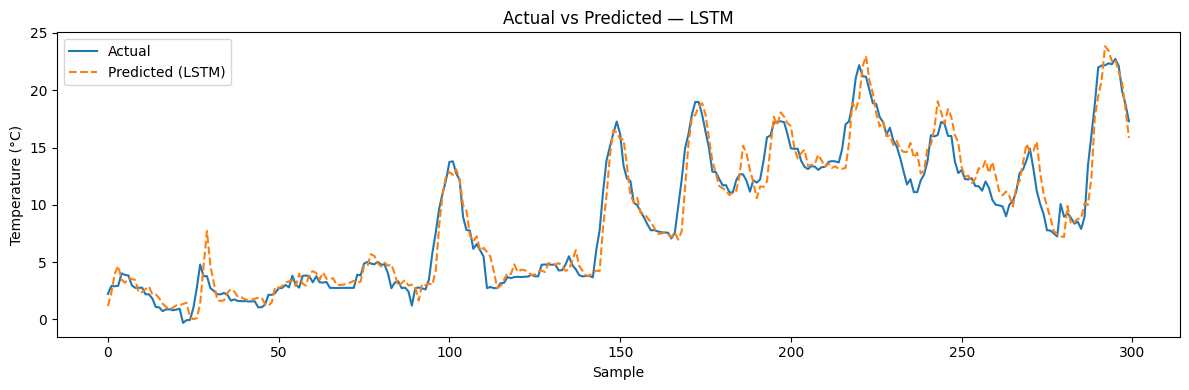

In [7]:
lstm_model = Sequential([
    LSTM(26, return_sequences=True, input_shape=(TIME_STEPS, X.shape[2])),
    Dropout(0.3),
    LSTM(26),
    Dense(1)
], name='LSTM')

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=50,           # increased from original 10 for fair comparison
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# Predict & inverse transform
lstm_pred = scaler_y.inverse_transform(lstm_model.predict(X_test))
y_test_orig = scaler_y.inverse_transform(y_test)

all_results.append(evaluate_and_plot('LSTM', y_test_orig, lstm_pred))

## 8. SimpleRNN

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2411/2411 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - loss: 0.0075 - val_loss: 0.0019
Epoch 2/50
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.0024 - val_loss: 0.0015
Epoch 3/50
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.0020 - val_loss: 0.0015
Epoch 4/50
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.0019 - val_loss: 0.0014
Epoch 5/50
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 0.0017 - val_loss: 0.0013
Epoch 6/50
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 0.0017 - val_loss: 0.0016
Epoch 7/50
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 0.0016 - val_loss: 0.0012
Epoch 8/50
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 0.0018 - val_loss: 0.0015
Epoch 9/50
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 0.0017 - val_loss: 0.0013
Epoch 10/50
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 0.0017 - val_loss: 0.0013
Epoch 11/50
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 0.0016 - val_loss: 0.0014
Epoch 12/50
2411/2411 ━━━━━━━━

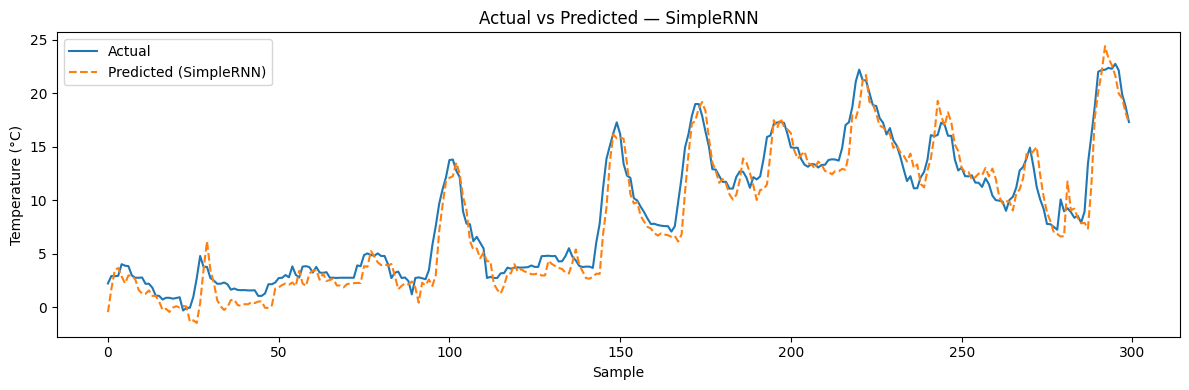

In [8]:
rnn_model = Sequential([
    SimpleRNN(52, return_sequences=True, input_shape=(TIME_STEPS, X.shape[2])),
    Dropout(0.3),
    SimpleRNN(52),
    Dense(1)
], name='SimpleRNN')

rnn_model.compile(optimizer='adam', loss='mse')

rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

rnn_pred = scaler_y.inverse_transform(rnn_model.predict(X_test))
all_results.append(evaluate_and_plot('SimpleRNN', y_test_orig, rnn_pred))

## 9. GRU

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2411/2411 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 0.0036 - val_loss: 0.0016
Epoch 2/50
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.0019 - val_loss: 0.0014
Epoch 3/50
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.0017 - val_loss: 0.0013
Epoch 4/50
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.0015 - val_loss: 0.0012
Epoch 5/50
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 6/50
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 7/50
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 8/50
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 9/50
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.0013 - val_loss: 0.0010
Epoch 10/50
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 0.0012 - val_loss: 0.0010
Epoch 11/50
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.0012 - val_loss: 0.0011
Epoch 12/50
2411/2411 ━━━━━━━━

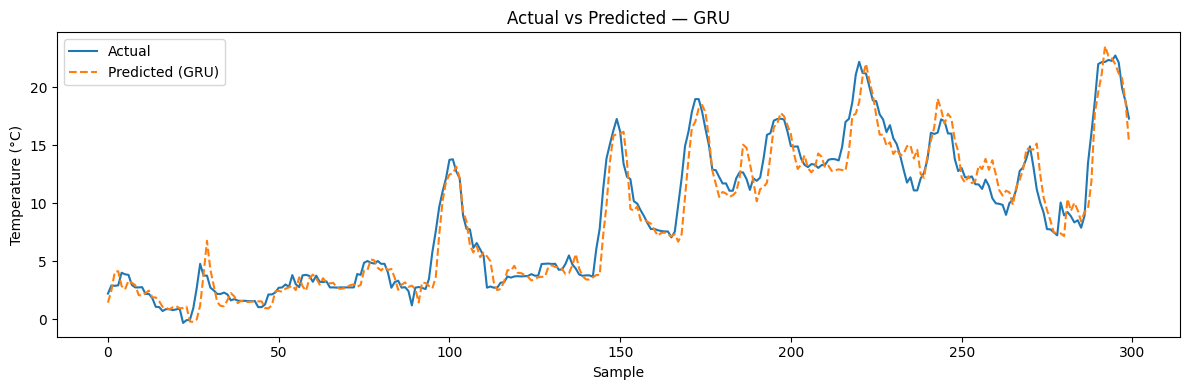

In [9]:
gru_model = Sequential([
    GRU(30, return_sequences=True, input_shape=(TIME_STEPS, X.shape[2])),
    Dropout(0.3),
    GRU(30),
    Dense(1)
], name='GRU')

gru_model.compile(optimizer='adam', loss='mse')

gru_history = gru_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

gru_pred = scaler_y.inverse_transform(gru_model.predict(X_test))
all_results.append(evaluate_and_plot('GRU', y_test_orig, gru_pred))

## 10. Final Comparison

In [10]:
comparison_df = pd.DataFrame(all_results).sort_values('R2', ascending=False)
print('\n===== Deep Learning Model Comparison =====')
print(comparison_df.to_string(index=False))

# Add classical ML best result for reference
classical_best = {'Model': 'HistGBT (classical, engineered features)', 'MAE': None, 'RMSE': 1.43, 'R2': 0.9747}
full_comparison = pd.concat([comparison_df, pd.DataFrame([classical_best])], ignore_index=True)

print('\n===== Deep Learning vs Classical ML =====')
print(full_comparison[['Model','R2','RMSE']].to_string(index=False))
full_comparison.to_csv('deep_learning_vs_classical_comparison.csv', index=False)


===== Deep Learning Model Comparison =====
    Model    MAE   RMSE     R2
     LSTM 1.1179 1.6480 0.9663
      GRU 1.1429 1.6616 0.9658
SimpleRNN 1.2863 1.8200 0.9589

===== Deep Learning vs Classical ML =====
                                   Model     R2   RMSE
                                    LSTM 0.9663 1.6480
                                     GRU 0.9658 1.6616
                               SimpleRNN 0.9589 1.8200
HistGBT (classical, engineered features) 0.9747 1.4300


/tmp/ipykernel_58/199290505.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  full_comparison = pd.concat([comparison_df, pd.DataFrame([classical_best])], ignore_index=True)


## 11. Training Loss Curves

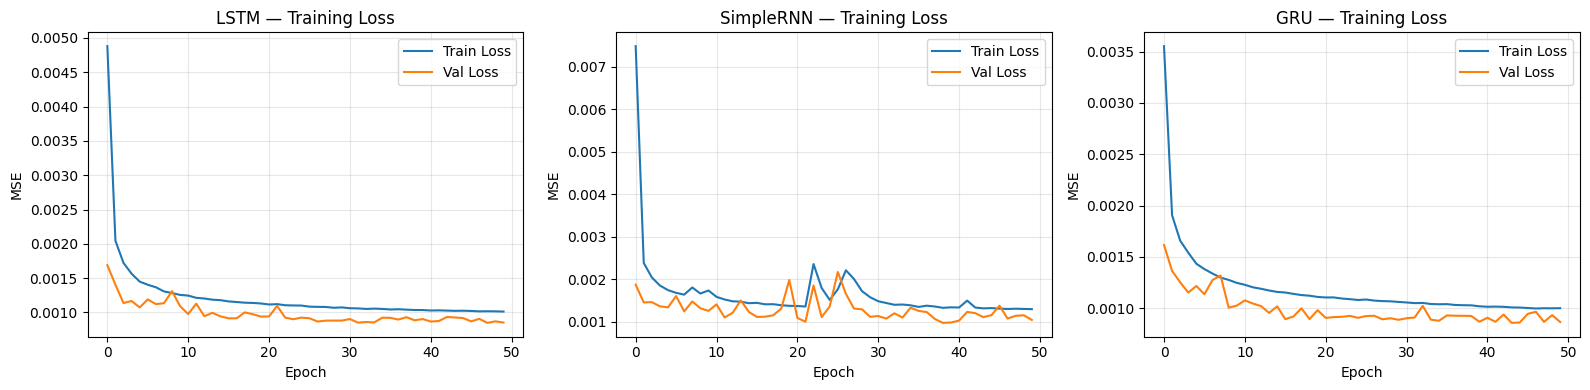

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, history, name in zip(axes,
    [lstm_history, rnn_history, gru_history],
    ['LSTM', 'SimpleRNN', 'GRU']):
    ax.plot(history.history['loss'],     label='Train Loss')
    ax.plot(history.history['val_loss'], label='Val Loss')
    ax.set_title(f'{name} — Training Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_loss_curves.png', dpi=150)
plt.show()